# `v_n` - `epsilon_n` 线性回归分析

这个 notebook 读取 Blast_wave 当前 ROOT 输出中的 `events` 树，做事件级线性响应分析：

\[
v_{n|\Psi_n} = \kappa_n\,\epsilon_n + c_n.
\]

默认分析两组主响应：

- `events.eps2` 对 `events.v2_wrt_psi2`
- `events.eps3` 对 `events.v3_wrt_psi3`

这里刻意使用 `v2_wrt_psi2` / `v3_wrt_psi3`，而不是 `v2` / `v3` 的模长。前者是末态 Q-vector 投影到初态 participant plane 后的带符号响应量，更适合直接检查线性响应斜率；`v2` / `v3` 是非负模长，容易把方向涨落折叠进去。


新增的 `v2_lab_x=<cos 2phi>` / `v2_lab_y=<sin 2phi>` 只作为 lab-frame 符号和坐标诊断量：它们保留固定实验室坐标下的二阶 Q-vector 分量，可用来检查 x/y 取向翻转；主响应斜率仍应优先看 `v2_wrt_psi2`。


## 环境与 uproot 支持

推荐使用本目录里的 `root_notebook` conda 环境文件：

```bash
conda env create -f notebooks/environment-notebook_with_root.yml
conda activate root_notebook
python -m ipykernel install --user --name root_notebook --display-name "root_notebook"
```

这个环境只包含 `uproot`、`numpy`、`pandas`、`matplotlib`、`scipy`、`jupyterlab` 和 `ipykernel` 等 Python 分析栈，不再安装完整 ROOT/PyROOT。

本 notebook 的读取路径是 `uproot`，用于直接读取 ROOT 文件中的 `events` tree 和对象键；不需要当前 kernel 提供 `import ROOT`。

In [1]:
# Load the Python analysis stack used by the event-tree regression path.
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)

## 输入文件组选择与多文件对比

`INPUT_FILE_GROUPS` 是多组比较入口。每一组都有独立的 ROOT 文件列表；notebook 会对每组分别读取 `events` tree、应用同一组 event cuts、做同一套 event-level linear regression，并为该组单独画 overlay 图。

默认保留三组输入：

- `glauber_direct`：`qa/*_glauber.root`，对应 Glauber 直接生成的初态
- `manual_third_order`：`qa/test_023_dense_mix.root`、`qa/test_023_newrap.root`、`qa/test_023_ellipse.root`，对应人工加入三阶初态的 response-test 数据
- `response_023_fluct`：`qa/test_023_dense_fluct.root`、`qa/test_023_dense_newrap_fluct.root`、`qa/test_023_ellipse_fluct.root`，对应 023 加入随机波动分布后的结果

这些组不会互相 overlay 或互相做差；每个图只比较同组里的 `dense_mix`、`newrap`、`ellipse`。若要比较自己的扫描结果，直接把下面的 `INPUT_FILE_GROUPS` 改成对应分组即可。

注意：`qa/` 里可能有旧 schema 文件。若某个文件缺少 `events.eps2/eps3` 或 `events.v2_wrt_psi2/v3_wrt_psi3`，读取阶段会跳过该文件并打印原因。


In [2]:
# Resolve the repository root whether the notebook is opened from repo root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Grouped multi-file inputs. Each group is analyzed independently, so Glauber and manual-v3 samples are not overlaid.
DEFAULT_INPUT_GROUP_CANDIDATES = {
    "glauber_direct": {
        "title": "Glauber direct initial geometry",
        "files": [
            (PROJECT_ROOT / "qa" / "test_023_dense_mix_glauber.root", "dense_mix"),
            (PROJECT_ROOT / "qa" / "test_023_newrap_glauber.root", "newrap"),
            (PROJECT_ROOT / "qa" / "test_023_ellipse_glauber.root", "ellipse"),
        ],
    },
    "manual_third_order": {
        "title": "Manual 0+2+3 response-test initial geometry",
        "files": [
            (PROJECT_ROOT / "qa" / "test_023_dense_mix.root", "dense_mix"),
            (PROJECT_ROOT / "qa" / "test_023_newrap.root", "newrap"),
            (PROJECT_ROOT / "qa" / "test_023_ellipse.root", "ellipse"),
        ],
    },
    "response_023_fluct": {
        "title": "023 response-test with random fluctuation distribution",
        "files": [
            (PROJECT_ROOT / "qa" / "test_023_dense_fluct.root", "dense_mix"),
            (PROJECT_ROOT / "qa" / "test_023_dense_newrap_fluct.root", "newrap"),
            (PROJECT_ROOT / "qa" / "test_023_ellipse_fluct.root", "ellipse"),
        ],
    },
}
INPUT_FILE_GROUPS = DEFAULT_INPUT_GROUP_CANDIDATES

# Plotting controls. Regression is always done on raw event rows; binned means are visual guides only.
PLOT_RAW_SCATTER = False
PROFILE_BINS = 12
SCATTER_MAX_POINTS = 20000


def normalise_input_files(entries, *, group_key):
    specs = []
    seen_labels = set()
    for entry in entries:
        if isinstance(entry, (str, Path)):
            path = Path(entry)
            label = path.stem
        else:
            path = Path(entry[0])
            label = str(entry[1]) if len(entry) > 1 else path.stem

        if not path.is_absolute():
            path = PROJECT_ROOT / path
        path = path.resolve()
        if not path.exists():
            print(f"[skip] {group_key}/{label}: file does not exist: {path}")
            continue
        if label in seen_labels:
            raise ValueError(f"Duplicate input label {label!r} in group {group_key!r}; labels must be unique within a plot.")
        seen_labels.add(label)
        specs.append({"group_key": group_key, "path": path, "label": label})
    return specs


# Normalize user-editable group definitions into a list consumed by every downstream analysis step.
def normalise_input_groups(group_definitions):
    groups = []
    for group_key, group_definition in group_definitions.items():
        if isinstance(group_definition, dict):
            group_title = group_definition.get("title", group_key)
            entries = group_definition.get("files", [])
        else:
            group_title = group_key
            entries = group_definition

        specs = normalise_input_files(entries, group_key=group_key)
        if not specs:
            print(f"[skip group] {group_key}: no existing ROOT input files were configured.")
            continue
        groups.append({"key": group_key, "title": group_title, "input_files": specs})

    if groups:
        return groups

    candidates = sorted((PROJECT_ROOT / "qa").glob("*.root"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No ROOT files found under {PROJECT_ROOT / 'qa'}")
    latest = candidates[0].resolve()
    return [{
        "key": "latest_file",
        "title": "Latest available QA ROOT file",
        "input_files": [{"group_key": "latest_file", "path": latest, "label": latest.stem}],
    }]


analysis_groups = normalise_input_groups(INPUT_FILE_GROUPS)
input_files = analysis_groups[0]["input_files"]  # Backward-compatible first-group handle for optional cells.
ROOT_FILE = input_files[0]["path"]               # Backward-compatible first-file handle for optional cells.

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print("Configured input groups:")
for group in analysis_groups:
    print(f"  [{group['key']}] {group['title']}")
    for spec in group["input_files"]:
        print(f"    {spec['label']}: {spec['path']}")


PROJECT_ROOT = /Users/allenzhou/Research_software/Blast_wave
Configured input groups:
  [glauber_direct] Glauber direct initial geometry
    dense_mix: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_mix_glauber.root
    newrap: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_newrap_glauber.root
    ellipse: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_ellipse_glauber.root
  [manual_third_order] Manual 0+2+3 response-test initial geometry
    dense_mix: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_mix.root
    newrap: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_newrap.root
    ellipse: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_ellipse.root
  [response_023_fluct] 023 response-test with random fluctuation distribution
    dense_mix: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_fluct.root
    newrap: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_newrap_fluct.root
  

In [3]:
# Inspect top-level objects and verify that the event tree is present in each configured file.
inspection_rows = []
for group in analysis_groups:
    for spec in group["input_files"]:
        try:
            with uproot.open(str(spec["path"])) as root_file:
                top_level_keys = [key.split(";")[0] for key in root_file.keys()]
                if "events" not in root_file:
                    raise KeyError("missing required 'events' tree")
                event_tree = root_file["events"]
                event_branches = sorted(event_tree.keys())
                inspection_rows.append({
                    "analysis_group": group["key"],
                    "group_title": group["title"],
                    "label": spec["label"],
                    "path": str(spec["path"]),
                    "top_level_objects": ", ".join(top_level_keys),
                    "n_event_branches": len(event_branches),
                    "event_branches": ", ".join(event_branches),
                })
        except Exception as exc:
            inspection_rows.append({
                "analysis_group": group["key"],
                "group_title": group["title"],
                "label": spec["label"],
                "path": str(spec["path"]),
                "top_level_objects": "",
                "n_event_branches": 0,
                "event_branches": f"ERROR: {exc}",
            })

inspection_table = pd.DataFrame(inspection_rows)
display(inspection_table)


,analysis_group,group_title,label,path,top_level_objects,n_event_branches,event_branches
0,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
1,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
2,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
3,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
4,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, events, participants, Np...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
5,manual_third_order,Manual 0+2+3 response-test initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
6,response_023_fluct,023 response-test with random fluctuation dist...,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
7,response_023_fluct,023 response-test with random fluctuation dist...,newrap,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."
8,response_023_fluct,023 response-test with random fluctuation dist...,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,"particles, particles, participants, participan...",31,"Nch, Npart, R_rms_init, b, centrality, chi2, e..."


## 读取 `events` 树

当前 notebook 只依赖事件级分支：

- 初态几何：`eps2`, `eps3`
- 末态投影响应：`v2_wrt_psi2`, `v3_wrt_psi3`
- 可选筛选/权重：`centrality`, `Npart`, `Nch`
- 对照观察：`v2`, `v3`

In [4]:
# Read the event-level branches needed for regression and common filters.
REQUIRED_BRANCHES = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
OPTIONAL_BRANCHES = ["event_id", "centrality", "Npart", "Nch", "v2", "v3", "v2_lab_x", "v2_lab_y", "eps2_f", "chi2"]


def read_event_table(input_spec):
    with uproot.open(str(input_spec["path"])) as root_file:
        event_tree = root_file["events"]
        event_branches = set(event_tree.keys())
        missing_required = [branch for branch in REQUIRED_BRANCHES if branch not in event_branches]
        if missing_required:
            raise KeyError(f"missing required event branches: {missing_required}")

        branches_to_read = []
        for branch in REQUIRED_BRANCHES + OPTIONAL_BRANCHES:
            if branch in event_branches and branch not in branches_to_read:
                branches_to_read.append(branch)
        events_for_file = event_tree.arrays(branches_to_read, library="pd")
        events_for_file["analysis_group"] = input_spec["group_key"]
        events_for_file["source_label"] = input_spec["label"]
        return events_for_file


event_tables_by_group = {}
valid_analysis_groups = []
read_rows = []
for group in analysis_groups:
    group_key = group["key"]
    group_event_tables = {}
    valid_input_files = []
    for spec in group["input_files"]:
        try:
            table = read_event_table(spec)
        except Exception as exc:
            print(f"[skip] {group_key}/{spec['label']}: {exc}")
            continue

        group_event_tables[spec["label"]] = table
        valid_input_files.append(spec)
        read_rows.append({
            "analysis_group": group_key,
            "group_title": group["title"],
            "label": spec["label"],
            "path": str(spec["path"]),
            "n_events": len(table),
            "n_branches": len(table.columns),
        })

    if valid_input_files:
        event_tables_by_group[group_key] = group_event_tables
        valid_analysis_groups.append({**group, "input_files": valid_input_files})
    else:
        print(f"[skip group] {group_key}: no files could be read with the required event-level response branches.")

if not valid_analysis_groups:
    raise RuntimeError("No configured ROOT files could be read with the required event-level response branches.")

analysis_groups = valid_analysis_groups
first_group_key = analysis_groups[0]["key"]
input_files = analysis_groups[0]["input_files"]
event_tables = event_tables_by_group[first_group_key]  # Backward-compatible first-group table map.
ROOT_FILE = input_files[0]["path"]
events = event_tables[input_files[0]["label"]]        # Backward-compatible first-file table.
read_summary = pd.DataFrame(read_rows)
display(read_summary)
display(events.head())


,analysis_group,group_title,label,path,n_events,n_branches
0,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
1,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
2,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
3,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
4,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
5,manual_third_order,Manual 0+2+3 response-test initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
6,response_023_fluct,023 response-test with random fluctuation dist...,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
7,response_023_fluct,023 response-test with random fluctuation dist...,newrap,/Users/allenzhou/Research_software/Blast_wave/...,5000,16
8,response_023_fluct,023 response-test with random fluctuation dist...,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,5000,16


,eps2,eps3,v2_wrt_psi2,v3_wrt_psi3,event_id,centrality,Npart,Nch,v2,v3,v2_lab_x,v2_lab_y,eps2_f,chi2,analysis_group,source_label
0,0.356540,0.253128,0.091743,0.038071,0,60.422961,182,352,0.108758,0.050570,0.101464,0.039157,0.356540,1.0,glauber_direct,dense_mix
1,0.520971,0.221225,0.082961,0.107278,1,60.422961,154,277,0.123062,0.131941,0.107117,0.060583,0.520971,1.0,glauber_direct,dense_mix
2,0.073340,0.073307,-0.003349,-0.034058,2,60.422961,210,396,0.020059,0.037949,-0.019670,0.003929,0.073340,1.0,glauber_direct,dense_mix
3,0.161119,0.239782,-0.000997,-0.016548,3,60.422961,166,302,0.127798,0.025513,0.095392,0.085045,0.161119,1.0,glauber_direct,dense_mix
4,0.288510,0.013905,0.066225,-0.000991,4,60.422961,188,420,0.070140,0.005414,0.067212,0.020054,0.288510,1.0,glauber_direct,dense_mix


In [5]:
# Configure event-level cuts and optional weights in one place. The same cuts are applied to every group and file.
CENTRALITY_RANGE = None  # Example: (0.0, 50.0)
NCH_MIN = None           # Example: 20
EPSILON_MIN = 0.0        # Raise this if near-zero epsilon events dominate numerical ratios.
WEIGHT_COLUMN = None     # Example: "Nch"; keep None for ordinary least squares.

# Apply finite-value and physics-motivated event filters before fitting.
def select_events(data: pd.DataFrame) -> pd.DataFrame:
    selected = data.copy()

    finite_columns = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
    finite_mask = np.ones(len(selected), dtype=bool)
    for column in finite_columns:
        finite_mask &= np.isfinite(selected[column].to_numpy(dtype=float))
    selected = selected.loc[finite_mask]

    if CENTRALITY_RANGE is not None and "centrality" in selected:
        low, high = CENTRALITY_RANGE
        selected = selected[(selected["centrality"] >= low) & (selected["centrality"] < high)]

    if NCH_MIN is not None and "Nch" in selected:
        selected = selected[selected["Nch"] >= NCH_MIN]

    if EPSILON_MIN > 0.0:
        selected = selected[(selected["eps2"] >= EPSILON_MIN) & (selected["eps3"] >= EPSILON_MIN)]

    return selected.reset_index(drop=True)


selected_events_by_group = {}
selection_rows = []
for group in analysis_groups:
    group_key = group["key"]
    selected_events_for_group = {}
    for spec in group["input_files"]:
        label = spec["label"]
        selected = select_events(event_tables_by_group[group_key][label])
        selected_events_for_group[label] = selected
        selection_rows.append({
            "analysis_group": group_key,
            "group_title": group["title"],
            "label": label,
            "input_events": len(event_tables_by_group[group_key][label]),
            "selected_events": len(selected),
        })
    selected_events_by_group[group_key] = selected_events_for_group

selected_events_by_file = selected_events_by_group[first_group_key]  # Backward-compatible first-group selection map.
selected_events = selected_events_by_file[input_files[0]["label"]]  # Backward-compatible first-file selection.
selection_summary = pd.DataFrame(selection_rows)
display(selection_summary)
display(selected_events.describe().T)


,analysis_group,group_title,label,input_events,selected_events
0,glauber_direct,Glauber direct initial geometry,dense_mix,5000,5000
1,glauber_direct,Glauber direct initial geometry,newrap,5000,5000
2,glauber_direct,Glauber direct initial geometry,ellipse,5000,5000
3,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,5000,5000
4,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,5000,5000
5,manual_third_order,Manual 0+2+3 response-test initial geometry,ellipse,5000,5000
6,response_023_fluct,023 response-test with random fluctuation dist...,dense_mix,5000,5000
7,response_023_fluct,023 response-test with random fluctuation dist...,newrap,5000,5000
8,response_023_fluct,023 response-test with random fluctuation dist...,ellipse,5000,5000


,count,mean,std,min,25%,50%,75%,max
eps2,5000.0,0.262620,1.052078e-01,0.006100,0.188272,0.261813,0.337842,0.625250
eps3,5000.0,0.191337,9.989070e-02,0.001136,0.116366,0.179526,0.257958,0.594883
v2_wrt_psi2,5000.0,0.019020,5.881721e-02,-0.226445,-0.021244,0.018639,0.058757,0.224840
v3_wrt_psi3,5000.0,0.029104,4.663117e-02,-0.147237,-0.002409,0.029006,0.060667,0.228166
event_id,5000.0,2499.500000,1.443520e+03,0.000000,1249.750000,2499.500000,3749.250000,4999.000000
centrality,5000.0,60.422961,7.106138e-15,60.422961,60.422961,60.422961,60.422961,60.422961
Npart,5000.0,180.791600,1.660712e+01,124.000000,170.000000,181.000000,192.000000,236.000000
Nch,5000.0,361.651600,4.399529e+01,211.000000,332.000000,360.000000,391.000000,535.000000
v2,5000.0,0.076401,3.998566e-02,0.000810,0.046531,0.071578,0.101429,0.274383
v3,5000.0,0.062324,3.293533e-02,0.000787,0.037520,0.058641,0.082664,0.241107


## 回归实现

下面的 helper 使用普通最小二乘或可选加权最小二乘。同阶响应默认报告两类斜率：

- `slope_free_intercept`: 拟合 `v = slope * eps + intercept`
- `slope_through_origin`: 强制过原点的响应斜率，近似对应理想线性响应里的 `kappa_n`

交叉阶 mixing 检查（`v2_wrt_psi2` 对 `eps3`、`v3_wrt_psi3` 对 `eps2`）只保留自由截距拟合；这两组不是同阶线性响应系数，所以不强制过原点。

如果同阶响应的自由截距接近 0，过原点斜率通常更容易解释；如果自由截距明显偏离 0，应优先检查低 multiplicity、centrality 混合或模型里是否存在非线性/背景偏置。

In [6]:
# Solve a linear least-squares model and return compact diagnostics.
def linear_fit(x_values, y_values, weights=None, *, intercept=True):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
        w = w[mask]
    else:
        w = np.ones(np.count_nonzero(mask), dtype=float)

    x = x[mask]
    y = y[mask]
    if x.size < (2 if intercept else 1):
        raise ValueError("Not enough finite points for linear regression.")

    design = np.column_stack([np.ones_like(x), x]) if intercept else x[:, None]
    sqrt_w = np.sqrt(w)
    weighted_design = design * sqrt_w[:, None]
    weighted_y = y * sqrt_w

    beta, *_ = np.linalg.lstsq(weighted_design, weighted_y, rcond=None)
    fitted = design @ beta
    residuals = y - fitted

    n_points = x.size
    n_params = design.shape[1]
    dof = max(n_points - n_params, 0)
    ss_res = float(np.sum(w * residuals * residuals))
    y_mean = float(np.average(y, weights=w))
    ss_tot = float(np.sum(w * (y - y_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

    normal_matrix = weighted_design.T @ weighted_design
    sigma2 = ss_res / dof if dof > 0 else np.nan
    covariance = np.linalg.pinv(normal_matrix) * sigma2 if np.isfinite(sigma2) else np.full((n_params, n_params), np.nan)
    stderr = np.sqrt(np.diag(covariance))

    if intercept:
        intercept_value = float(beta[0])
        slope_value = float(beta[1])
        intercept_stderr = float(stderr[0])
        slope_stderr = float(stderr[1])
    else:
        intercept_value = 0.0
        slope_value = float(beta[0])
        intercept_stderr = np.nan
        slope_stderr = float(stderr[0])

    pearson_r = float(np.corrcoef(x, y)[0, 1]) if n_points > 1 and np.std(x) > 0.0 and np.std(y) > 0.0 else np.nan

    return {
        "n": int(n_points),
        "intercept": intercept_value,
        "intercept_stderr": intercept_stderr,
        "slope": slope_value,
        "slope_stderr": slope_stderr,
        "r2": r2,
        "pearson_r": pearson_r,
        "rmse": math.sqrt(ss_res / n_points),
        "residuals": residuals,
        "fitted": fitted,
    }

# Compute binned means for plotting the response trend over noisy event scatter.
def binned_profile(x_values, y_values, *, bins=12):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size == 0 or np.nanmin(x) == np.nanmax(x):
        return pd.DataFrame(columns=["x", "y", "yerr", "count"])

    edges = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), bins + 1)
    bin_index = np.digitize(x, edges, right=False) - 1
    bin_index = np.clip(bin_index, 0, bins - 1)

    rows = []
    for index in range(bins):
        in_bin = bin_index == index
        if not np.any(in_bin):
            continue
        y_bin = y[in_bin]
        rows.append({
            "x": float(np.mean(x[in_bin])),
            "y": float(np.mean(y_bin)),
            "yerr": float(np.std(y_bin, ddof=1) / math.sqrt(y_bin.size)) if y_bin.size > 1 else 0.0,
            "count": int(y_bin.size),
        })
    return pd.DataFrame(rows)

In [7]:
# Run same-harmonic response fits for each group and summarize free-intercept and through-origin slopes.
RESPONSE_PAIRS = {
    "n=2 response": {"epsilon": "eps2", "response": "v2_wrt_psi2", "harmonic": 2},
    "n=3 response": {"epsilon": "eps3", "response": "v3_wrt_psi3", "harmonic": 3},
}


def weights_for(data: pd.DataFrame):
    if WEIGHT_COLUMN is None:
        return None
    if WEIGHT_COLUMN not in data:
        raise KeyError(f"WEIGHT_COLUMN={WEIGHT_COLUMN!r} is not present in the events table.")
    return data[WEIGHT_COLUMN].to_numpy(dtype=float)


# Fit one pair set inside a single analysis group; different groups are never mixed in one regression or plot.
def fit_pair_set(pair_specs: dict, group: dict, *, include_origin=True):
    group_key = group["key"]
    all_results = {pair_label: {} for pair_label in pair_specs}
    rows = []

    for input_spec in group["input_files"]:
        file_label = input_spec["label"]
        data = selected_events_by_group[group_key][file_label]
        weights = weights_for(data)

        for pair_label, spec in pair_specs.items():
            x = data[spec["epsilon"]].to_numpy(dtype=float)
            y = data[spec["response"]].to_numpy(dtype=float)
            fit_free = linear_fit(x, y, weights=weights, intercept=True)
            fit_origin = linear_fit(x, y, weights=weights, intercept=False) if include_origin else None

            result = {"free": fit_free, "origin": fit_origin, "file_label": file_label, "pair_label": pair_label, **spec}
            all_results[pair_label][file_label] = result

            row = {
                "analysis_group": group_key,
                "group_title": group["title"],
                "file_label": file_label,
                "file_path": str(input_spec["path"]),
                "label": pair_label,
                "n_events": fit_free["n"],
                "epsilon": spec["epsilon"],
                "response": spec["response"],
                "slope_free_intercept": fit_free["slope"],
                "slope_free_stderr": fit_free["slope_stderr"],
                "intercept": fit_free["intercept"],
                "intercept_stderr": fit_free["intercept_stderr"],
                "r2_free": fit_free["r2"],
                "pearson_r": fit_free["pearson_r"],
                "rmse_free": fit_free["rmse"],
            }
            if fit_origin is not None:
                row.update({
                    "slope_through_origin": fit_origin["slope"],
                    "slope_origin_stderr": fit_origin["slope_stderr"],
                    "rmse_origin": fit_origin["rmse"],
                })
            rows.append(row)

    return all_results, pd.DataFrame(rows)


fit_results_by_group = {}
summary_tables = []
for group in analysis_groups:
    group_results, group_summary = fit_pair_set(RESPONSE_PAIRS, group, include_origin=True)
    fit_results_by_group[group["key"]] = group_results
    summary_tables.append(group_summary)

summary = pd.concat(summary_tables, ignore_index=True)
fit_results = fit_results_by_group[first_group_key]  # Backward-compatible first-group result map.
display(summary)


,analysis_group,group_title,file_label,file_path,label,n_events,epsilon,response,slope_free_intercept,slope_free_stderr,intercept,intercept_stderr,r2_free,pearson_r,rmse_free,slope_through_origin,slope_origin_stderr,rmse_origin
0,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.161357,0.007571,-0.023355,0.002142,0.083303,0.288623,0.056308,0.084721,0.002848,0.056974
1,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.143064,0.006285,0.001730,0.001357,0.093920,0.306464,0.044383,0.150170,0.002909,0.044390
2,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.237132,0.009231,-0.045134,0.002611,0.116646,0.341534,0.068648,0.089034,0.003533,0.070670
3,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.252499,0.007362,0.002607,0.001589,0.190507,0.436472,0.051987,0.263207,0.003408,0.052001
4,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.232749,0.007620,-0.022559,0.002156,0.157304,0.396615,0.056671,0.158728,0.002864,0.057288
5,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,-0.199279,0.005879,-0.000613,0.001269,0.186921,-0.432344,0.041513,-0.201795,0.002720,0.041514
6,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.201227,0.009251,-0.002164,0.002510,0.086485,0.294084,0.035478,0.193414,0.001849,0.035481
7,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.090130,0.009354,-0.000363,0.001020,0.018237,0.135043,0.033051,0.087173,0.004287,0.033052
8,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=2 response,5000,eps2,v2_wrt_psi2,0.215138,0.009204,-0.007319,0.001977,0.098547,0.313922,0.036277,0.182226,0.002392,0.036327
9,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,n=3 response,5000,eps3,v3_wrt_psi3,0.122215,0.009553,-0.000755,0.001043,0.031712,0.178077,0.033915,0.116071,0.004396,0.033917


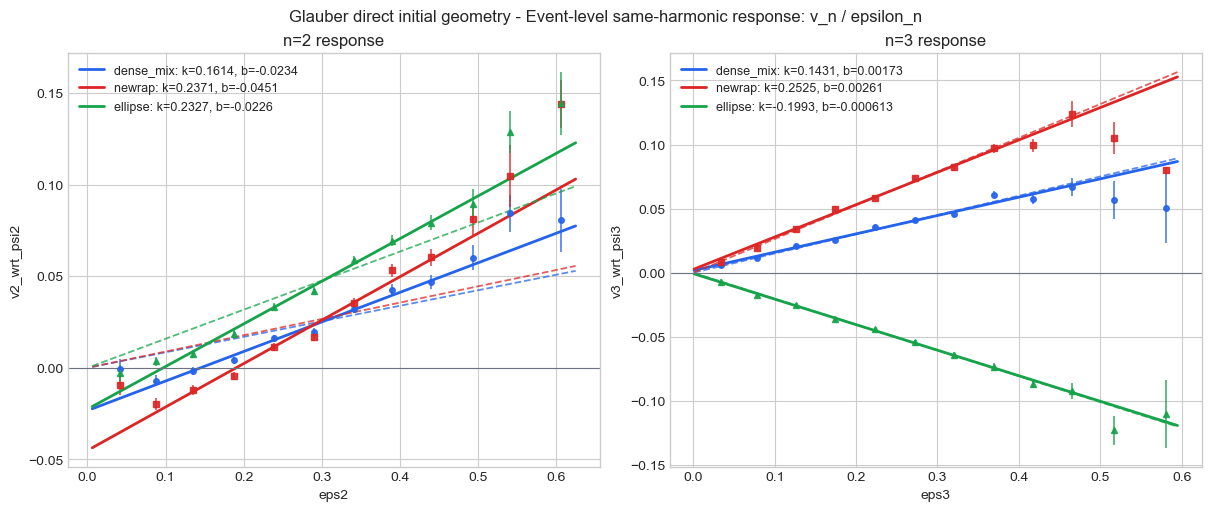

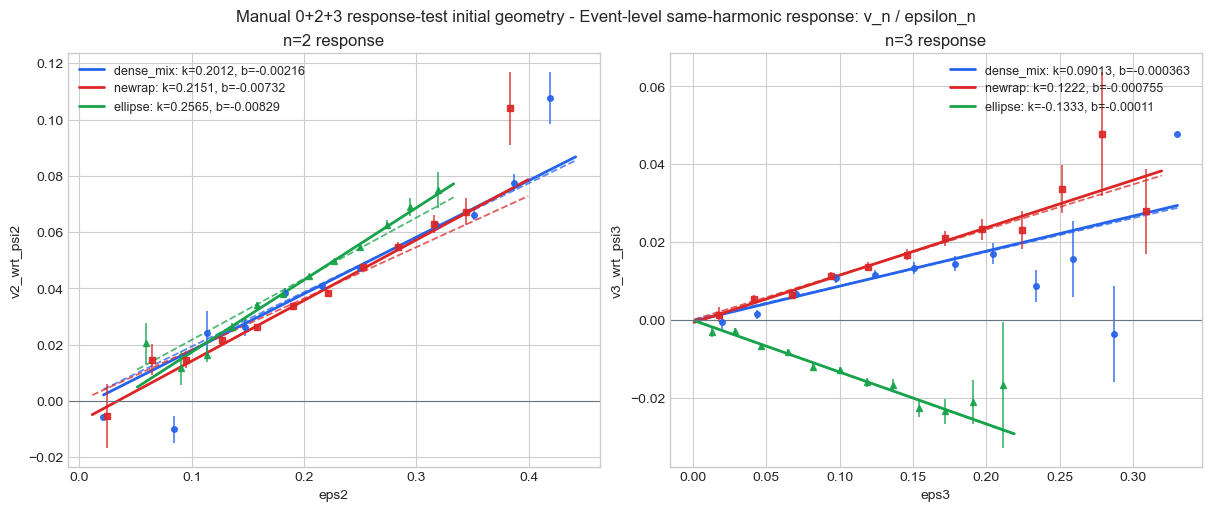

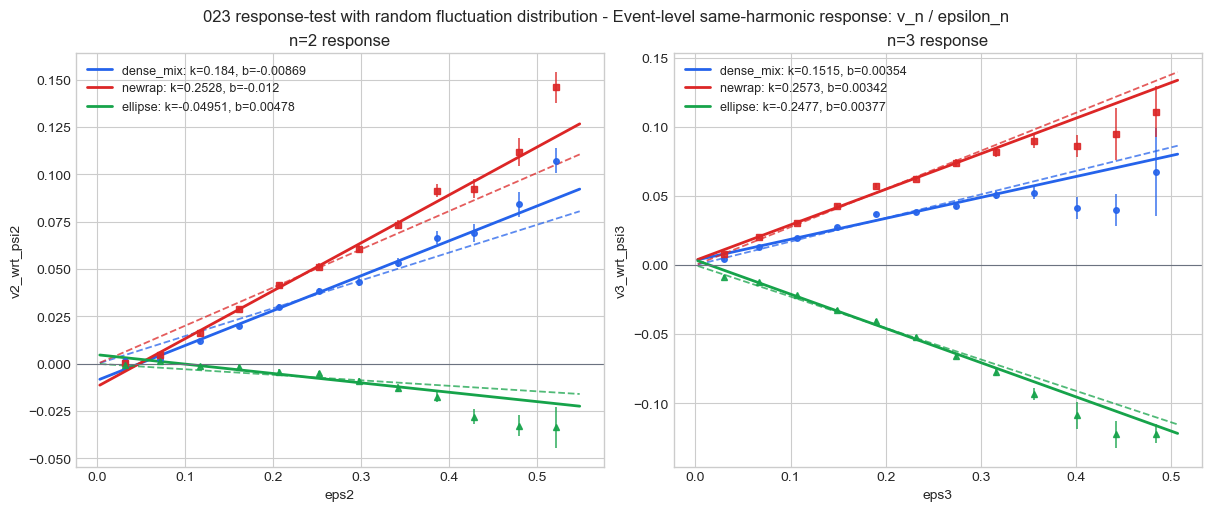

In [8]:
# Plot raw-event regression comparisons. Binned means are visual guides and do not enter the fit.
STYLE_CYCLE = [
    {"color": "#2563eb", "marker": "o"},
    {"color": "#dc2626", "marker": "s"},
    {"color": "#16a34a", "marker": "^"},
    {"color": "#9333ea", "marker": "D"},
    {"color": "#ea580c", "marker": "v"},
]


def finite_pair_mask(data: pd.DataFrame, spec: dict):
    x = data[spec["epsilon"]].to_numpy(dtype=float)
    y = data[spec["response"]].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if WEIGHT_COLUMN is not None:
        w = data[WEIGHT_COLUMN].to_numpy(dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
    return x, y, mask


def draw_one_pair(ax, pair_label: str, spec: dict, pair_results: dict, group: dict):
    group_key = group["key"]
    for style_index, input_spec in enumerate(group["input_files"]):
        file_label = input_spec["label"]
        if file_label not in pair_results:
            continue

        style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
        data = selected_events_by_group[group_key][file_label]
        x, y, mask = finite_pair_mask(data, spec)
        x = x[mask]
        y = y[mask]
        if x.size == 0:
            continue
        fit = pair_results[file_label]

        if PLOT_RAW_SCATTER:
            if x.size > SCATTER_MAX_POINTS:
                ax.hexbin(x, y, gridsize=60, mincnt=1, cmap="Greys", alpha=0.25)
            else:
                ax.scatter(x, y, s=8, alpha=0.12, linewidths=0, color=style["color"])

        profile = binned_profile(x, y, bins=PROFILE_BINS)
        if not profile.empty:
            ax.errorbar(
                profile["x"], profile["y"], yerr=profile["yerr"],
                fmt=style["marker"], color=style["color"], ms=4, lw=1.1, alpha=0.9,
            )

        x_line = np.linspace(float(np.min(x)), float(np.max(x)), 200)
        y_free = fit["free"]["intercept"] + fit["free"]["slope"] * x_line
        ax.plot(
            x_line, y_free, color=style["color"], lw=2.0,
            label=f"{file_label}: k={fit['free']['slope']:.4g}, b={fit['free']['intercept']:.3g}",
        )
        if fit.get("origin") is not None:
            y_origin = fit["origin"]["slope"] * x_line
            ax.plot(x_line, y_origin, color=style["color"], lw=1.3, ls="--", alpha=0.75)

    ax.axhline(0.0, color="#6b7280", lw=0.8)
    ax.set_title(pair_label)
    ax.set_xlabel(spec["epsilon"])
    ax.set_ylabel(spec["response"])
    ax.legend(frameon=False, fontsize=9)


def plot_pair_comparison(pair_specs: dict, all_results: dict, group: dict, title: str):
    fig, axes = plt.subplots(1, len(pair_specs), figsize=(6 * len(pair_specs), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, (pair_label, spec) in zip(axes, pair_specs.items()):
        draw_one_pair(ax, pair_label, spec, all_results[pair_label], group)
    fig.suptitle(f"{group['title']} - {title}")
    return fig, axes


same_harmonic_figs = {}
same_harmonic_axes_by_group = {}
for group in analysis_groups:
    fig, axes = plot_pair_comparison(
        RESPONSE_PAIRS,
        fit_results_by_group[group["key"]],
        group,
        "Event-level same-harmonic response: v_n / epsilon_n",
    )
    same_harmonic_figs[group["key"]] = fig
    same_harmonic_axes_by_group[group["key"]] = axes
    plt.show()

same_harmonic_fig = same_harmonic_figs[first_group_key]          # Backward-compatible first-group figure.
same_harmonic_axes = same_harmonic_axes_by_group[first_group_key]


## Cross-talk 检查

下面额外拟合 `v2_wrt_psi2` 对 `eps3`、`v3_wrt_psi3` 对 `eps2`。它们不是主响应斜率，但能快速暴露二阶/三阶初态混合、centrality 混合或模型响应串扰。

,analysis_group,group_title,file_label,file_path,label,n_events,epsilon,response,slope_free_intercept,slope_free_stderr,intercept,intercept_stderr,r2_free,pearson_r,rmse_free
0,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,-0.046615,0.008303,0.027939,0.001792,0.006267,-0.079167,0.058627
1,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.033236,0.006252,0.037832,0.001769,0.005623,-0.074986,0.046495
2,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,-0.070399,0.010296,0.030611,0.002222,0.009268,-0.096270,0.072701
3,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.024583,0.007762,0.057376,0.002196,0.002003,-0.044756,0.057723
4,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,-0.086591,0.008656,0.055134,0.001868,0.019627,-0.140097,0.061125
5,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,0.039413,0.006165,-0.049093,0.001744,0.008111,0.090060,0.045851
6,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,-0.012426,0.010504,0.052539,0.001145,0.000280,-0.016731,0.037114
7,manual_third_order,Manual 0+2+3 response-test initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.001261,0.008698,0.008707,0.002360,0.000004,-0.002051,0.033357
8,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2 wrt Psi2 vs eps3,5000,eps3,v2_wrt_psi2,0.008100,0.010761,0.036514,0.001174,0.000113,0.010646,0.038207
9,manual_third_order,Manual 0+2+3 response-test initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v3 wrt Psi3 vs eps2,5000,eps2,v3_wrt_psi3,-0.011868,0.008743,0.013548,0.001878,0.000369,-0.019199,0.034460


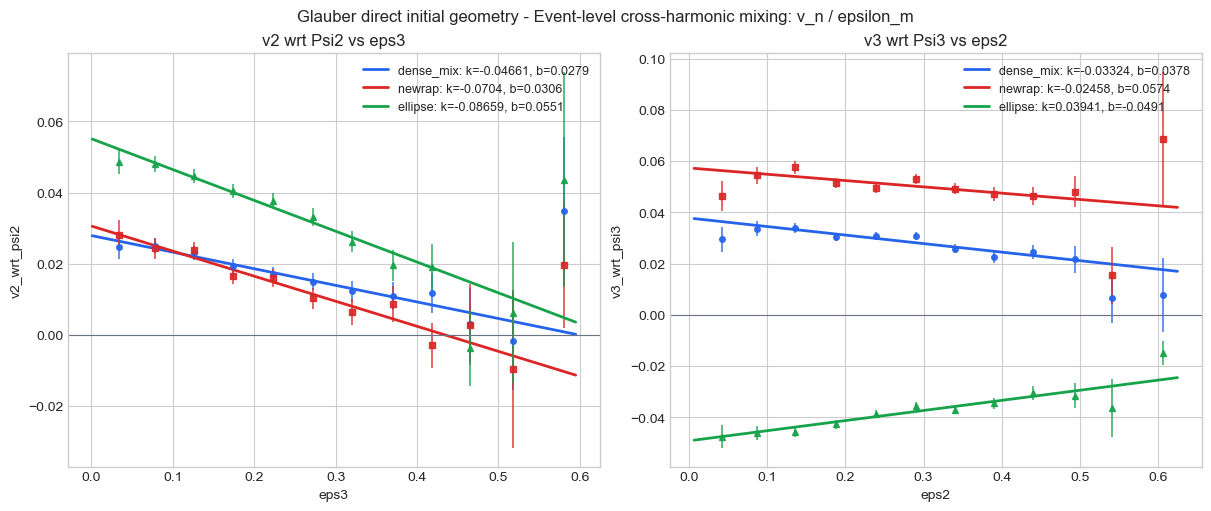

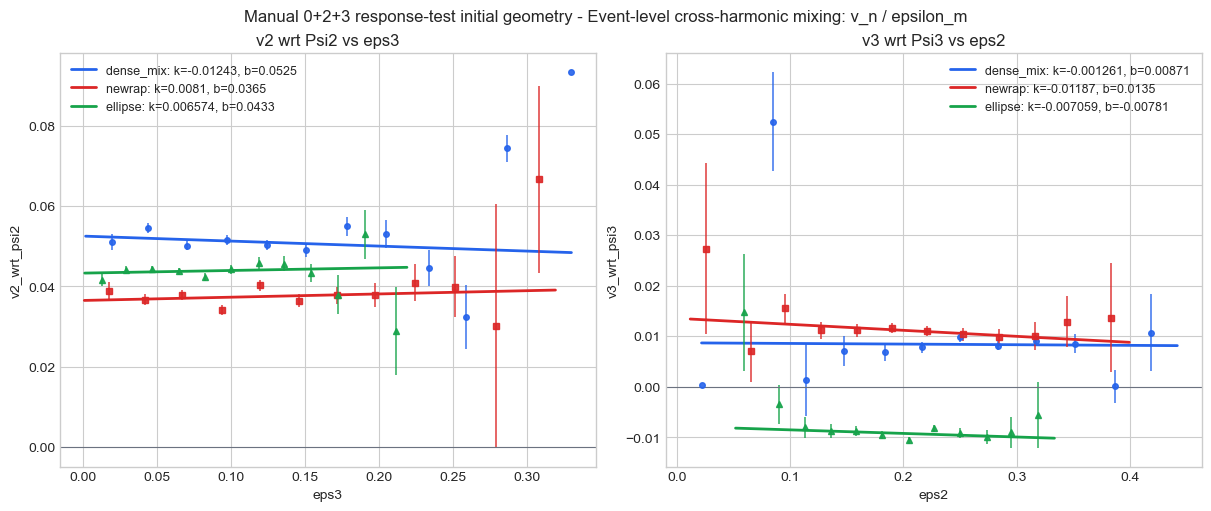

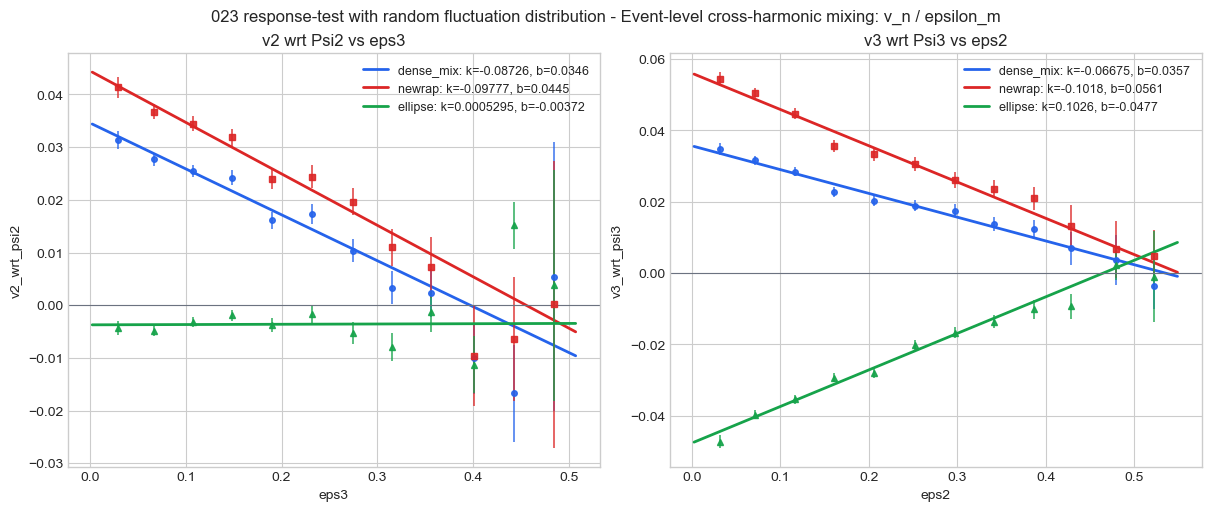

In [9]:
# Fit cross-harmonic pairs with a free intercept; these mixing checks do not define kappa_n.
CROSS_TALK_PAIRS = {
    "v2 wrt Psi2 vs eps3": {"epsilon": "eps3", "response": "v2_wrt_psi2"},
    "v3 wrt Psi3 vs eps2": {"epsilon": "eps2", "response": "v3_wrt_psi3"},
}

cross_fit_results_by_group = {}
cross_talk_tables = []
for group in analysis_groups:
    group_results, group_summary = fit_pair_set(CROSS_TALK_PAIRS, group, include_origin=False)
    cross_fit_results_by_group[group["key"]] = group_results
    cross_talk_tables.append(group_summary)

cross_talk_summary = pd.concat(cross_talk_tables, ignore_index=True)
cross_fit_results = cross_fit_results_by_group[first_group_key]  # Backward-compatible first-group result map.
display(cross_talk_summary)

cross_talk_figs = {}
cross_talk_axes_by_group = {}
for group in analysis_groups:
    fig, axes = plot_pair_comparison(
        CROSS_TALK_PAIRS,
        cross_fit_results_by_group[group["key"]],
        group,
        "Event-level cross-harmonic mixing: v_n / epsilon_m",
    )
    cross_talk_figs[group["key"]] = fig
    cross_talk_axes_by_group[group["key"]] = axes
    plt.show()

cross_talk_fig = cross_talk_figs[first_group_key]          # Backward-compatible first-group figure.
cross_talk_axes = cross_talk_axes_by_group[first_group_key]


## Lab-frame V2 诊断

这一节只在输入文件包含 `v2_lab_x` 和 `v2_lab_y` 时运行。`v2_lab_x` 是固定 lab-x 方向的 `⟨cos 2φ⟩`，最直接反映 x/y 取向符号；`v2_lab_y` 是对应的 `⟨sin 2φ⟩`，主要用于检查整体旋转或非对齐。


,analysis_group,group_title,file_label,file_path,label,n_events,epsilon,response,slope_free_intercept,slope_free_stderr,intercept,intercept_stderr,r2_free,pearson_r,rmse_free
0,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_x vs eps2,5000,eps2,v2_lab_x,0.219520,0.006991,-0.025553,0.001978,1.647630e-01,0.405910,0.051994
1,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_y vs eps2,5000,eps2,v2_lab_y,0.001634,0.007569,-0.000040,0.002141,9.326001e-06,0.003054,0.056291
2,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_x vs eps3,5000,eps3,v2_lab_x,-0.051533,0.008024,0.041958,0.001732,8.185347e-03,-0.090473,0.056658
3,glauber_direct,Glauber direct initial geometry,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_y vs eps3,5000,eps3,v2_lab_y,-0.007558,0.007971,0.001835,0.001720,1.798340e-04,-0.013410,0.056286
4,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_x vs eps2,5000,eps2,v2_lab_x,0.342570,0.008070,-0.055623,0.002283,2.650135e-01,0.514795,0.060015
5,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_y vs eps2,5000,eps2,v2_lab_y,0.011135,0.009418,-0.001697,0.002664,2.796384e-04,0.016722,0.070041
6,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_x vs eps3,5000,eps3,v2_lab_x,-0.076303,0.009855,0.048942,0.002127,1.185251e-02,-0.108869,0.069588
7,glauber_direct,Glauber direct initial geometry,newrap,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_y vs eps3,5000,eps3,v2_lab_y,-0.013461,0.009919,0.003803,0.002141,3.684071e-04,-0.019194,0.070038
8,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_x vs eps2,5000,eps2,v2_lab_x,0.278193,0.006347,-0.013819,0.001796,2.776223e-01,0.526899,0.047207
9,glauber_direct,Glauber direct initial geometry,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,v2_lab_y vs eps2,5000,eps2,v2_lab_y,-0.003482,0.007380,0.001611,0.002088,4.452932e-05,-0.006673,0.054886


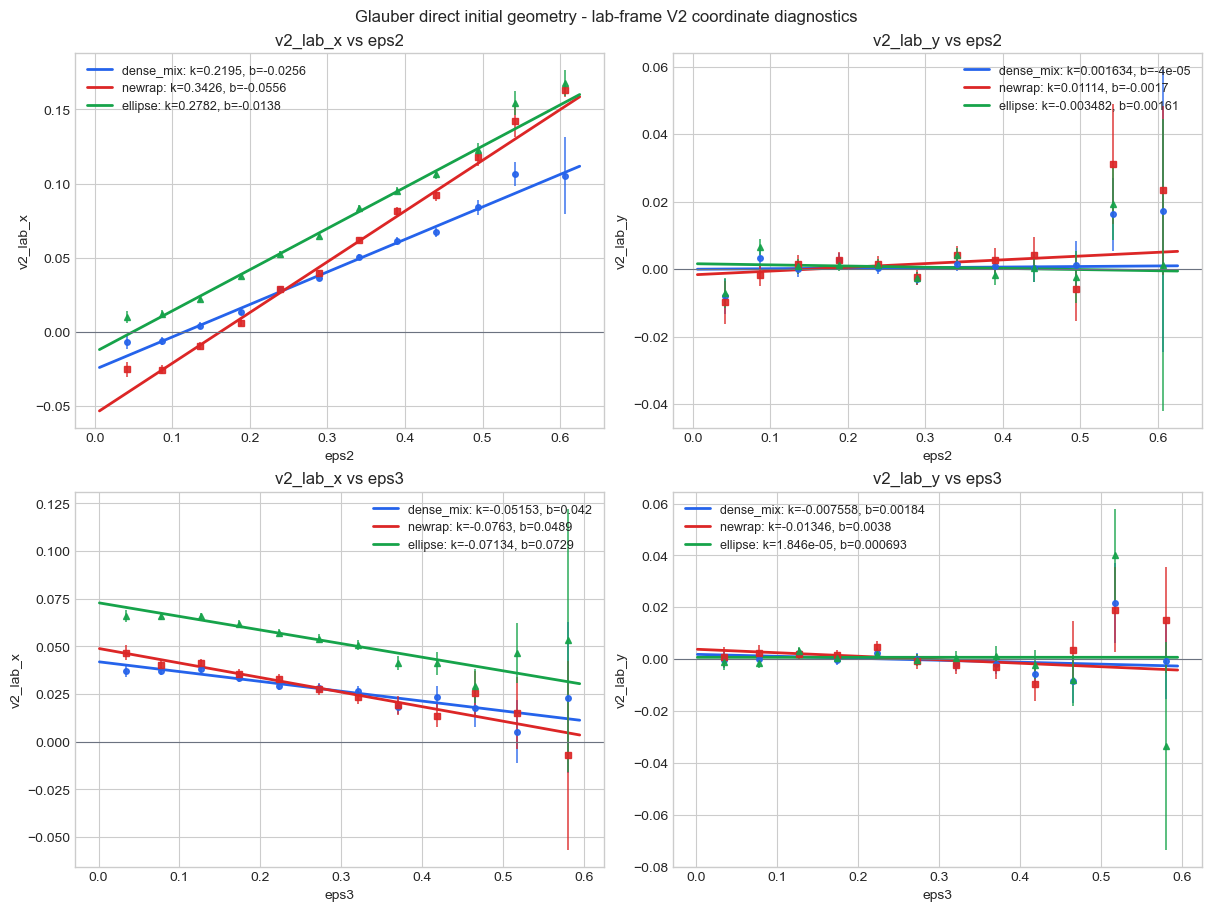

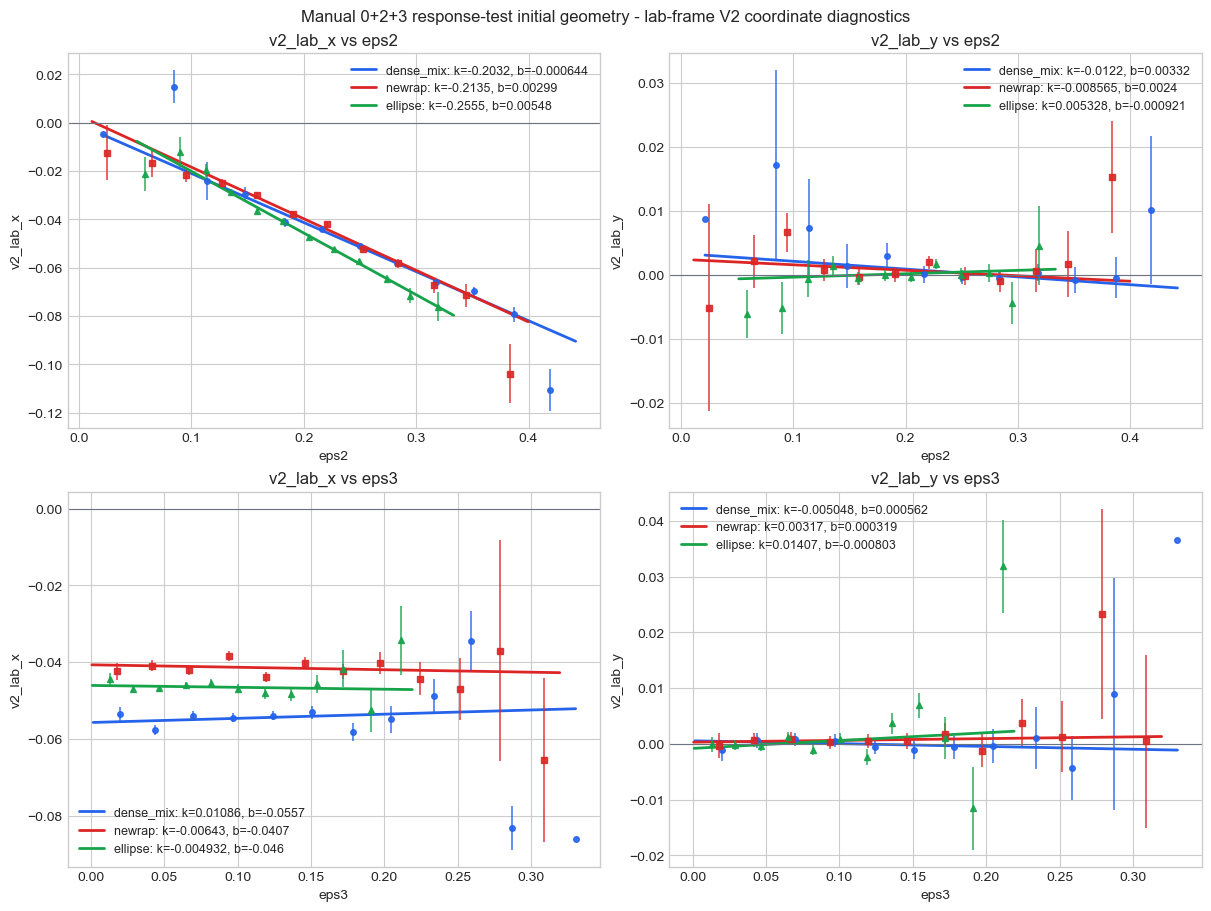

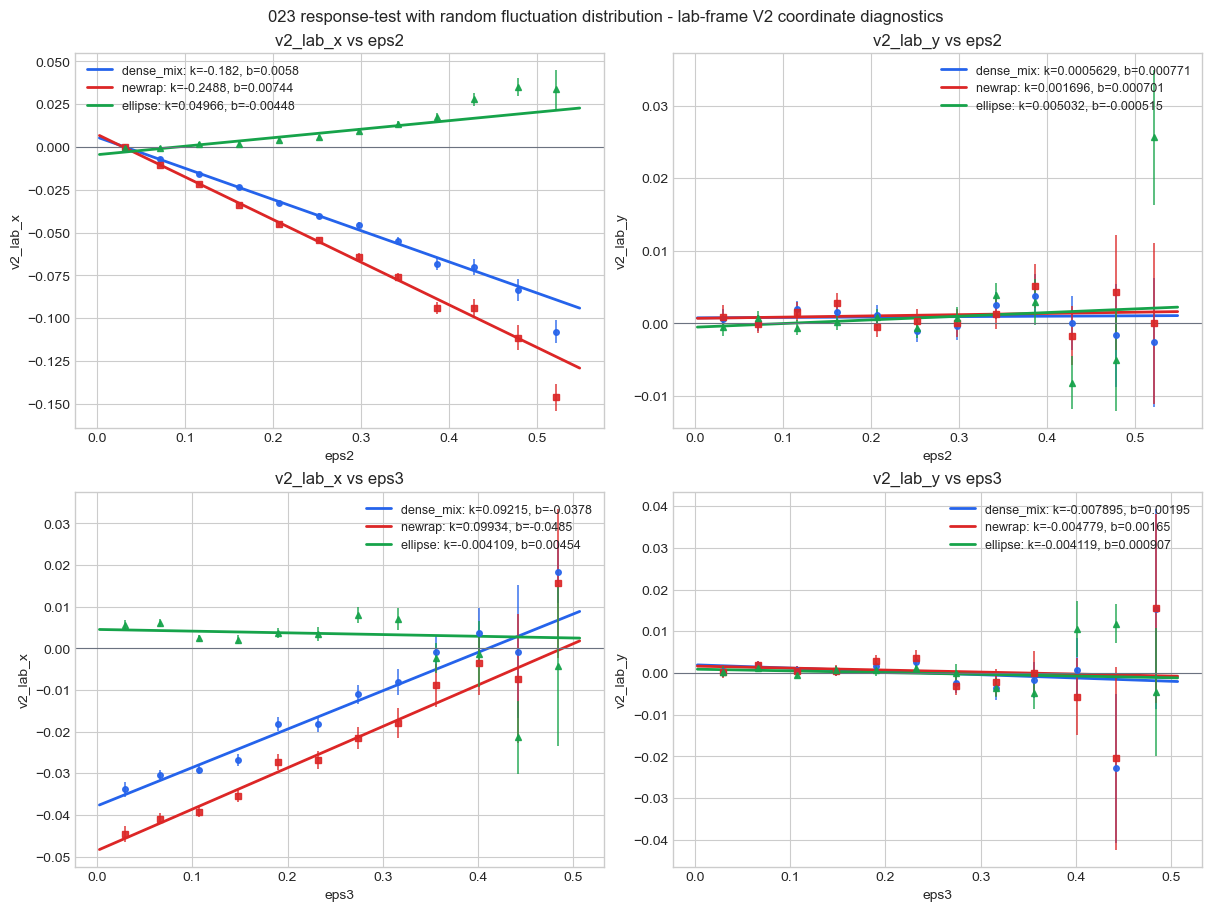

In [10]:
# Fit optional lab-frame V2 components with free intercepts as coordinate/sign diagnostics.
LAB_V2_BRANCHES = ["v2_lab_x", "v2_lab_y"]
LAB_V2_PAIRS = {
    "v2_lab_x vs eps2": {"epsilon": "eps2", "response": "v2_lab_x"},
    "v2_lab_y vs eps2": {"epsilon": "eps2", "response": "v2_lab_y"},
    "v2_lab_x vs eps3": {"epsilon": "eps3", "response": "v2_lab_x"},
    "v2_lab_y vs eps3": {"epsilon": "eps3", "response": "v2_lab_y"},
}


def group_with_lab_v2_inputs(group: dict):
    group_key = group["key"]
    lab_inputs = []
    for input_spec in group["input_files"]:
        label = input_spec["label"]
        data = selected_events_by_group[group_key][label]
        if all(branch in data.columns for branch in LAB_V2_BRANCHES):
            lab_inputs.append(input_spec)
    return {**group, "input_files": lab_inputs} if lab_inputs else None


lab_v2_groups = []
for group in analysis_groups:
    lab_group = group_with_lab_v2_inputs(group)
    if lab_group is not None:
        lab_v2_groups.append(lab_group)

lab_v2_fit_results_by_group = {}
lab_v2_figs = {}
lab_v2_axes_by_group = {}
if lab_v2_groups:
    lab_v2_tables = []
    for group in lab_v2_groups:
        group_results, group_summary = fit_pair_set(LAB_V2_PAIRS, group, include_origin=False)
        lab_v2_fit_results_by_group[group["key"]] = group_results
        lab_v2_tables.append(group_summary)

    lab_v2_summary = pd.concat(lab_v2_tables, ignore_index=True)
    display(lab_v2_summary)

    for group in lab_v2_groups:
        group_key = group["key"]
        fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
        for ax, (pair_label, spec) in zip(axes.ravel(), LAB_V2_PAIRS.items()):
            draw_one_pair(ax, pair_label, spec, lab_v2_fit_results_by_group[group_key][pair_label], group)
        fig.suptitle(f"{group['title']} - lab-frame V2 coordinate diagnostics")
        lab_v2_figs[group_key] = fig
        lab_v2_axes_by_group[group_key] = axes
        plt.show()
else:
    lab_v2_summary = pd.DataFrame()
    print("No v2_lab_x/v2_lab_y branches found; skipping lab-frame V2 diagnostics.")


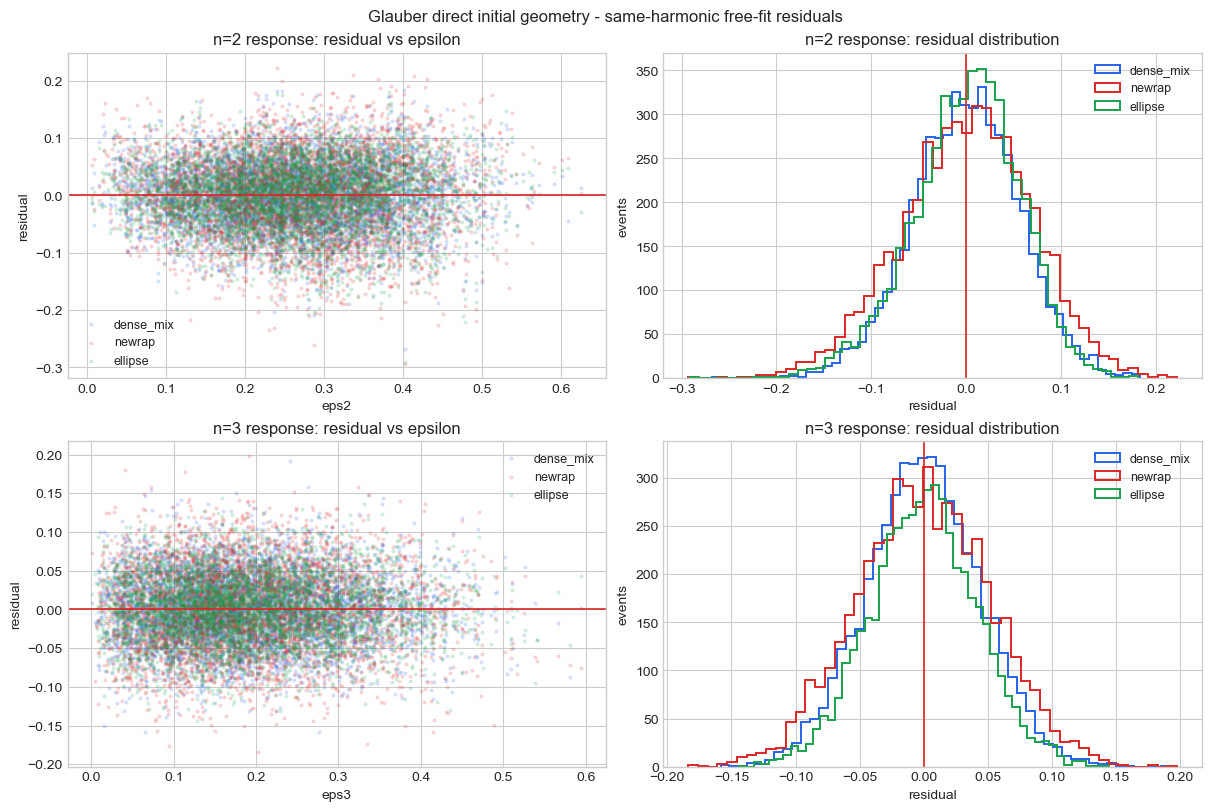

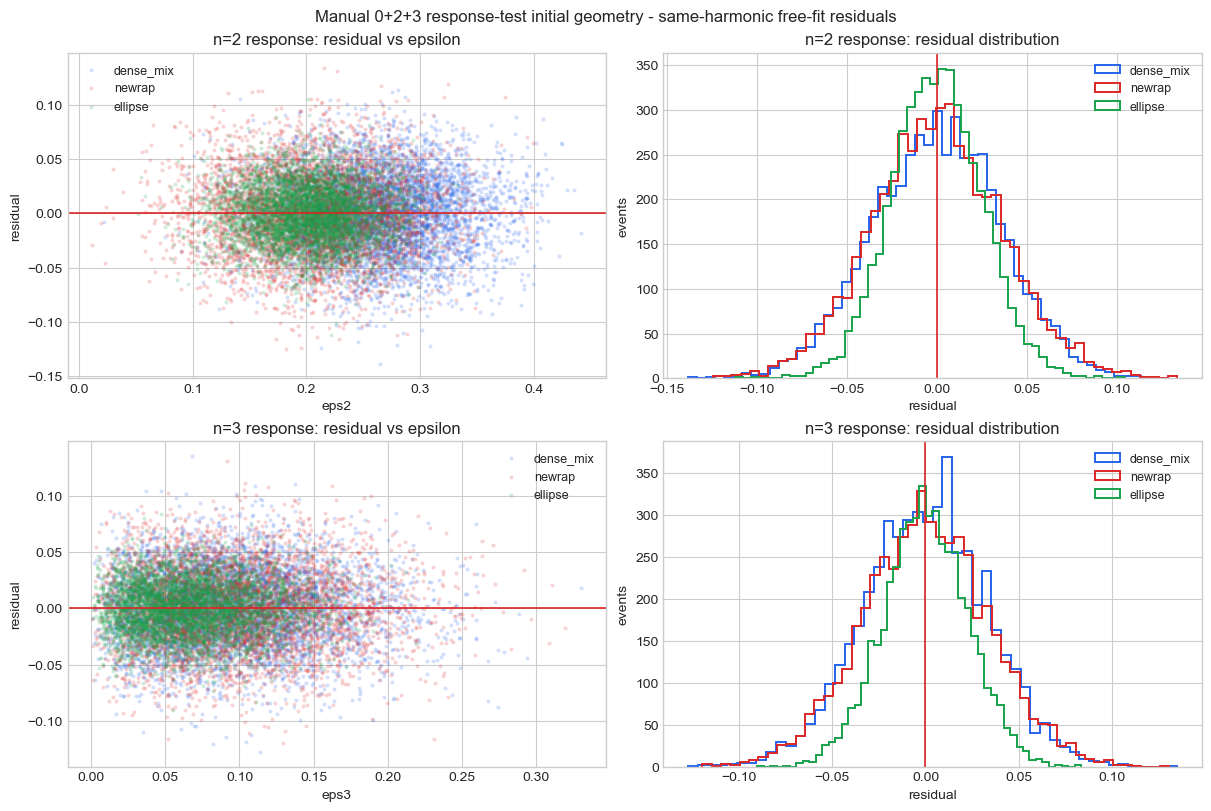

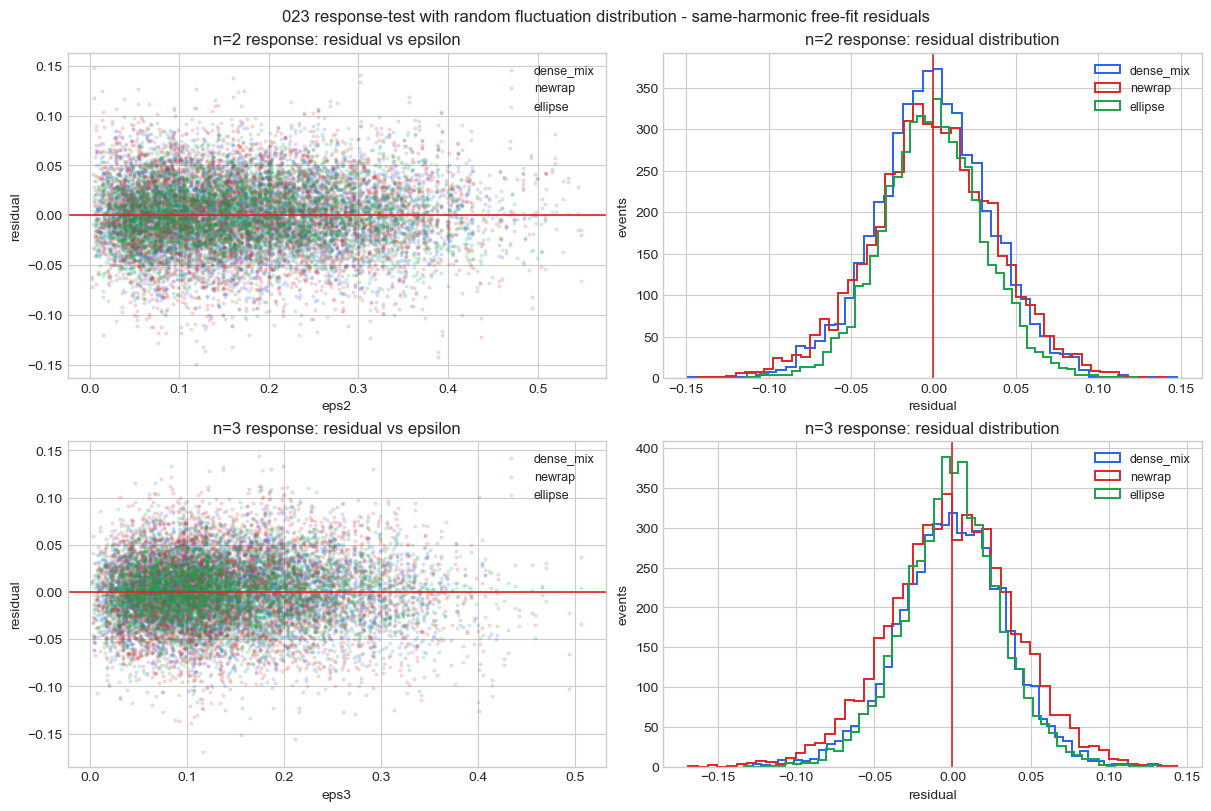

In [11]:
# Plot residuals from the same-harmonic free-intercept fits for every compared file in one group.
def plot_residual_comparison(pair_specs: dict, all_results: dict, group: dict):
    group_key = group["key"]
    fig, axes = plt.subplots(len(pair_specs), 2, figsize=(12, 4 * len(pair_specs)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row, (pair_label, spec) in enumerate(pair_specs.items()):
        ax_scatter, ax_hist = axes[row]
        for style_index, input_spec in enumerate(group["input_files"]):
            file_label = input_spec["label"]
            if file_label not in all_results[pair_label]:
                continue

            style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
            data = selected_events_by_group[group_key][file_label]
            x, _, mask = finite_pair_mask(data, spec)
            x = x[mask]
            residuals = all_results[pair_label][file_label]["free"]["residuals"]
            if x.size == 0:
                continue

            ax_scatter.scatter(x, residuals, s=8, alpha=0.20, linewidths=0, color=style["color"], label=file_label)
            ax_hist.hist(residuals, bins=50, histtype="step", lw=1.4, color=style["color"], label=file_label)

        ax_scatter.axhline(0.0, color="#dc2626", lw=1.2)
        ax_scatter.set_title(f"{pair_label}: residual vs epsilon")
        ax_scatter.set_xlabel(spec["epsilon"])
        ax_scatter.set_ylabel("residual")
        ax_scatter.legend(frameon=False, fontsize=9)

        ax_hist.axvline(0.0, color="#dc2626", lw=1.2)
        ax_hist.set_title(f"{pair_label}: residual distribution")
        ax_hist.set_xlabel("residual")
        ax_hist.set_ylabel("events")
        ax_hist.legend(frameon=False, fontsize=9)
    fig.suptitle(f"{group['title']} - same-harmonic free-fit residuals")
    return fig, axes


residual_figs = {}
residual_axes_by_group = {}
for group in analysis_groups:
    fig, axes = plot_residual_comparison(RESPONSE_PAIRS, fit_results_by_group[group["key"]], group)
    residual_figs[group["key"]] = fig
    residual_axes_by_group[group["key"]] = axes
    plt.show()

residual_fig = residual_figs[first_group_key]          # Backward-compatible first-group figure.
residual_axes = residual_axes_by_group[first_group_key]


## 可选：保存表格和图

默认不写文件。需要把结果落盘时，把 `SAVE_OUTPUTS` 改为 `True`。保存时，summary 表包含 `analysis_group` 字段；图像按输入组分别写出，避免人工三阶和 Glauber 的结果混在同一张图里。


In [12]:
# Persist compact regression summaries and per-group figures only when explicitly requested.
SAVE_OUTPUTS = False
OUTPUT_DIR = PROJECT_ROOT / "qa" / "vn_epsn_regression"

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    selection_summary.to_csv(OUTPUT_DIR / "vn_epsn_selection_summary.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "vn_epsn_regression_summary.csv", index=False)
    cross_talk_summary.to_csv(OUTPUT_DIR / "vn_epsn_cross_talk_summary.csv", index=False)
    if not lab_v2_summary.empty:
        lab_v2_summary.to_csv(OUTPUT_DIR / "vn_epsn_lab_v2_summary.csv", index=False)

    for group in analysis_groups:
        group_key = group["key"]
        same_harmonic_figs[group_key].savefig(OUTPUT_DIR / f"vn_epsn_{group_key}_same_harmonic_comparison.png", dpi=160)
        cross_talk_figs[group_key].savefig(OUTPUT_DIR / f"vn_epsn_{group_key}_cross_harmonic_comparison.png", dpi=160)
        residual_figs[group_key].savefig(OUTPUT_DIR / f"vn_epsn_{group_key}_residuals.png", dpi=160)
        if group_key in lab_v2_figs:
            lab_v2_figs[group_key].savefig(OUTPUT_DIR / f"vn_epsn_{group_key}_lab_v2_diagnostics.png", dpi=160)
    print(f"Saved regression tables and per-group comparison figures under {OUTPUT_DIR}")
else:
    print("SAVE_OUTPUTS is False; no files were written.")


SAVE_OUTPUTS is False; no files were written.
